# From FNN to RNN — Why Sequence Architecture Matters

## The Problem with FNN on Sequential Data

A FNN takes a flat vector as input. To use past information, you manually build a window of lagged returns:
```python
input = [return_t-5, return_t-4, return_t-3, return_t-2, return_t-1]  →  predict volatility_t
```

This works, but has three fundamental limitations.

---

## Limitation 1 — Order Blindness

The FNN assigns an independent weight to each lag. It has no built-in understanding that lag 1 and lag 2 are neighbors in time, or that one happened before the other. The temporal ordering only exists because you constructed the vector that way.

**Proof:** shuffle the elements of the input vector randomly — the FNN produces nearly identical results. An RNN would break completely.

---

## Limitation 2 — Fixed Hard Cutoff

You must decide upfront how many lags to include. If volatility clustering from 45 days ago is relevant today, a window of 30 days will never capture it — no matter how well you train the model.

---

## Limitation 3 — Parameter Explosion

Every extra lag adds a full set of input weights. With 60 days and 5 features, the first layer already has 300 weights just for the inputs. Doubling the window doubles the parameters.

---

## What the RNN Changes

Instead of consuming a flat vector, the RNN processes one time step at a time and maintains a **hidden state** — a compressed memory of everything seen so far.

The same weight matrix is reused at every step — so the number of parameters does not grow with sequence length.

---

## Why This Matters for Volatility Forecasting

Volatility clustering means high volatility today predicts high volatility tomorrow — and this effect can persist for **weeks or months**. A FNN with a 10-day window is structurally blind to anything beyond day 10.

The RNN hidden state accumulates this context automatically. A spike 3 weeks ago influences h_t-20, which flows into h_t-19, all the way to today's prediction. The network decides what to keep and what to forget — rather than you deciding upfront with a fixed window.

---

## What RNN Does Not Solve — The Vanishing Gradient

In practice the hidden state cannot carry information indefinitely. During backpropagation through many time steps, gradients shrink exponentially — the network effectively forgets anything beyond ~10-20 steps. This is the **vanishing gradient problem**, and it is the motivation for the LSTM.

In [19]:
import torch
import torch.nn as nn
import sys
sys.path.append('src')
from data_utils import *
from dl_utils.Operation import WeightMultiply
from dl_utils.NumberWithGrad import NumberWithGrad
from sklearn.model_selection import train_test_split
from dl_utils.Rnn import *
import pandas as pd
from model_analysis.Rnn_analysis import *
from copy import deepcopy

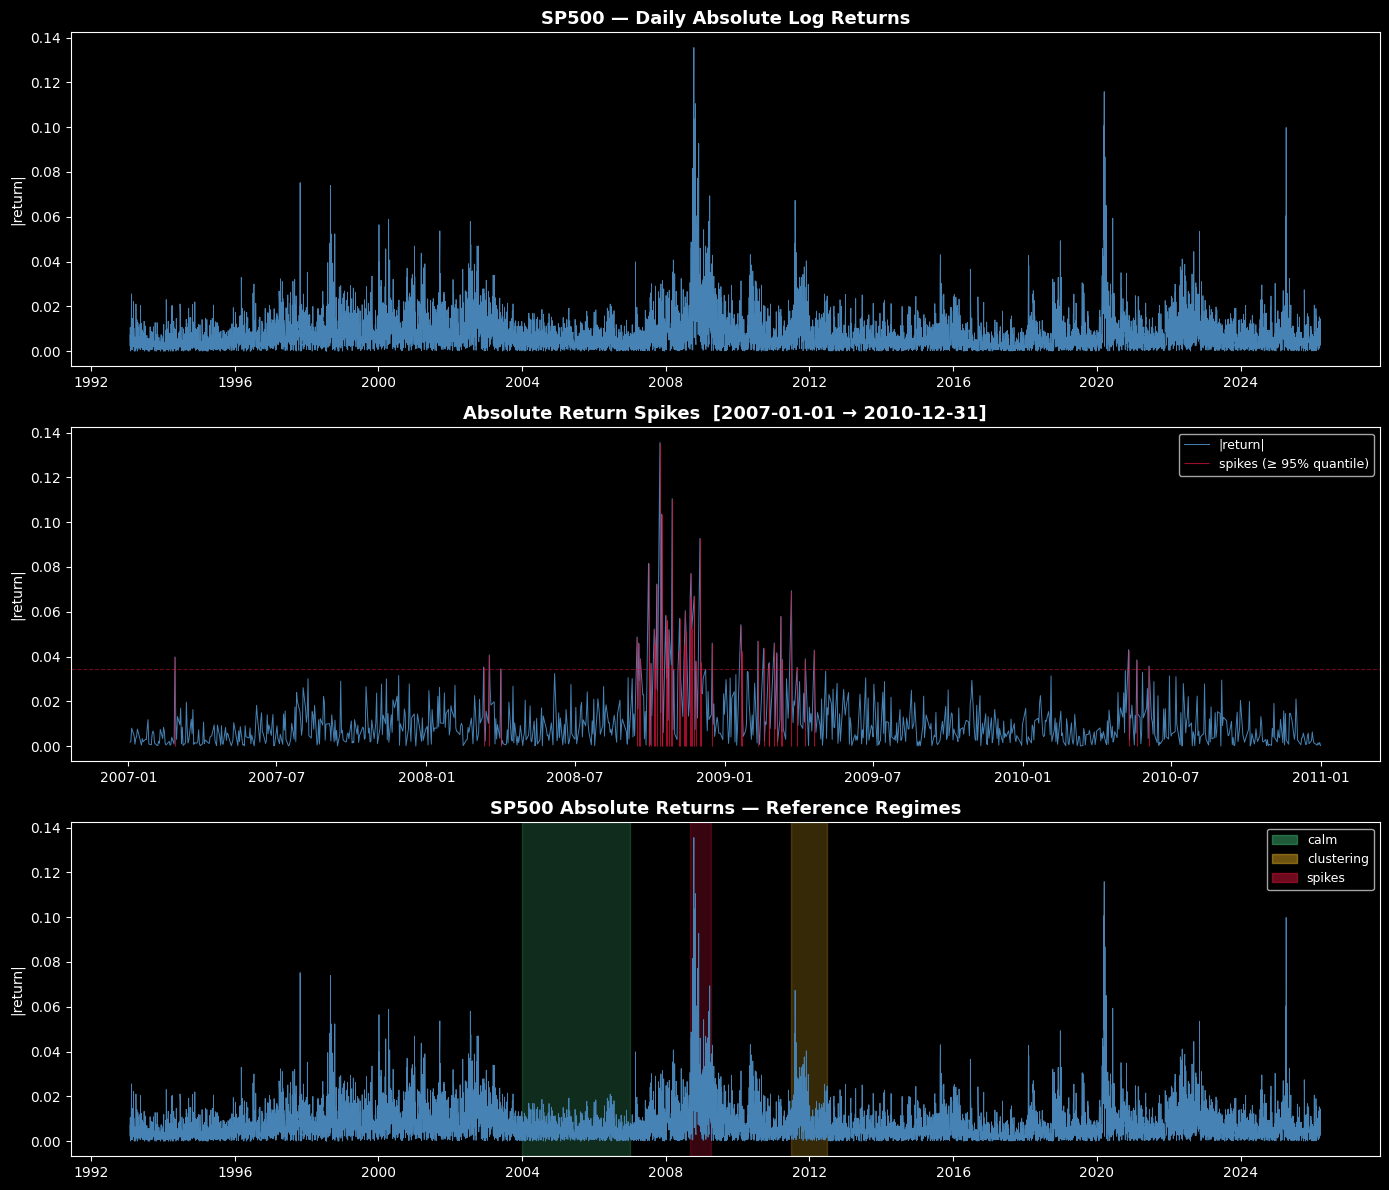

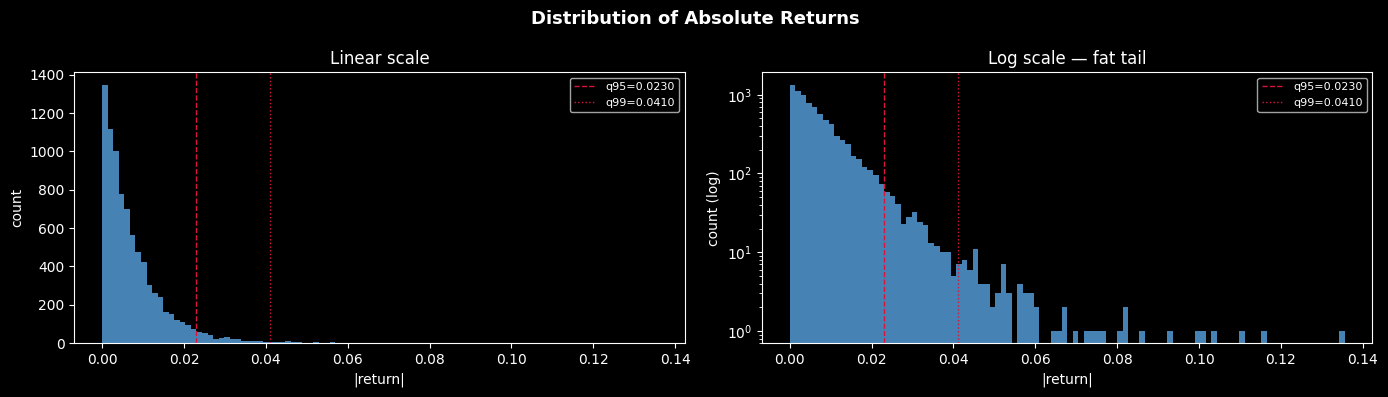

test_df: 545 rows across 3 regimes
  calm         2017-01-01 → 2017-12-31  (251 rows)
  clustering   2022-01-01 → 2022-12-31  (251 rows)
  spikes       2020-03-01 → 2020-04-30  (43 rows)
train_df: 7798 rows  (removed 545 test rows)
X_train: (6222, 20, 1)  X_val: (1556, 20, 1)
  calm          X: (231, 20, 1)
  clustering    X: (231, 20, 1)
  spikes        X: (23, 20, 1)


In [20]:
path_data = r"./data/df_sp_500_log_ret.csv"
df = pd.read_csv(path_data, index_col= "Date")
SEQUENCE_LENGTH = 20
plot_data_overview(df)
plot_abs_return_distribution(df) 
test_df = build_test_df(df, sequence_length=SEQUENCE_LENGTH)
X_train, y_train, X_val, y_val, regime_sets, scaler_X, scaler_y = prepare_datasets(df, test_df, sequence_length=SEQUENCE_LENGTH, test_size=0.2)
   

## Regime-Aware Test Set

The standard train/test split gives a single aggregate MAE — useful, but it hides where the model actually fails. A model can look decent on average while being completely wrong on the days that matter most (spikes, crisis periods).

To get a clearer picture, we isolate three post-2017 periods that were **never seen during training**, each representing a structurally different market regime:

| Regime | Period | Characteristic |
|--------|--------|----------------|
| **Calm** | 2017 | Small, stable daily moves — the easiest regime |
| **Clustering** | 2022 | Persistently elevated moves over a full year (Fed rate hike cycle) |
| **Spikes** | Mar–Apr 2020 | Extreme isolated moves (COVID crash) — never seen in training |

These three regimes are plotted below against the full series (greyed out).

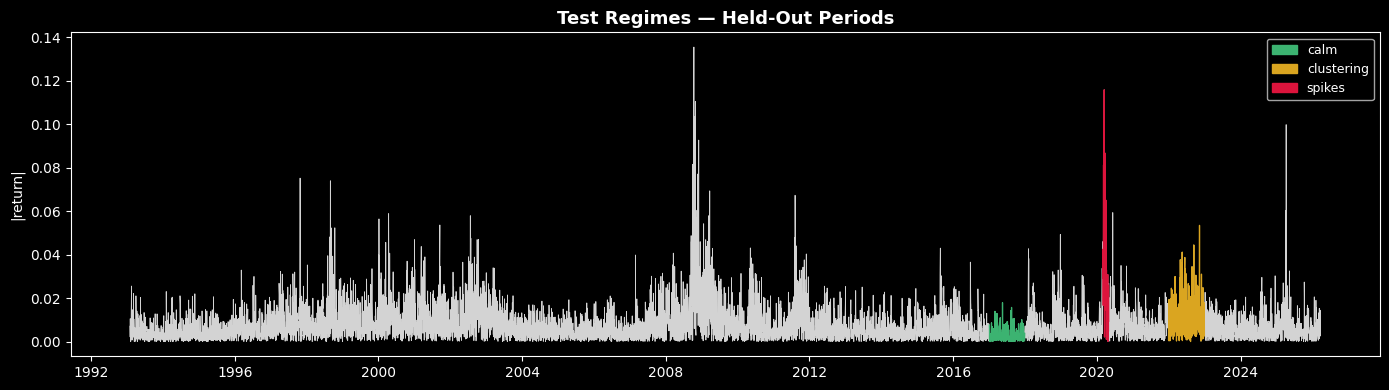

In [21]:
plot_test_regimes(df, test_df)

# Baseline RNN 

#

In [22]:
from sklearn.metrics import mean_absolute_error
INPUT_SIZE = X_train.shape[2]
OUTPUT_SIZE = y_train.shape[-1]

HIDDEN_SIZE = 64
NUM_LAYER = 1
NODE_ACTIVATION = "tanh"
DROPOUT = 0.0
BIDIRECTIONAL = False

HEAD_ACTIVATION = "none"   # linear output — required for regression
HEAD_DROPOUT = 0.0
HEAD_WEIGHT_INIT = 'xavier_uniform'
HEAD_BIAS_INIT = "zeros"


nn_head_1 = Dense(HIDDEN_SIZE, OUTPUT_SIZE,
                  HEAD_ACTIVATION, HEAD_DROPOUT,
                  True, HEAD_WEIGHT_INIT, HEAD_BIAS_INIT, False)


Rnn_simple = RNN(input_size=INPUT_SIZE,
                 hidden_size=HIDDEN_SIZE,
                 num_layers=NUM_LAYER,
                 nonlinearity=NODE_ACTIVATION,
                 rnn_dropout=DROPOUT,
                 bidirectional=BIDIRECTIONAL,
                 head=[nn_head_1])

Rnn_before =  deepcopy(Rnn_simple)
LOSS = 'mse'
OPTIMIZER = "adam"
LR = 0.0005
BATCH_SIZE = 64
N_EPOCH = 200
SHUFFLE = True
GRADIENT_CLIPPING = 0.5
EARLY_STOPPING = 30
VERBOSE = 10

trainer = Trainer(Rnn_simple, LOSS, OPTIMIZER, LR, BATCH_SIZE,
                  N_EPOCH, SHUFFLE, GRADIENT_CLIPPING, EARLY_STOPPING, VERBOSE)
trainer.fit(X_train, y_train, X_val, y_val)

# always: predict in scaled space → inverse_transform explicitly
y_pred_inv   = scaler_y.inverse_transform(trainer.predict(X_val).reshape(-1, 1))
y_val_inv = scaler_y.inverse_transform(y_val.reshape(-1, 1))
print(f"MAE: {mean_absolute_error(y_val_inv, y_pred_inv):.5f}")
y_pred = trainer.predict(X_val).reshape(-1, 1)
y_val = y_val.reshape(-1, 1)
print(f"MAE (not scaled): {mean_absolute_error(y_val, y_pred):.5f}")

epoch    0  train: 0.964002  test: 0.559984
epoch   10  train: 0.734930  test: 0.559540
epoch   20  train: 0.733114  test: 0.565723
epoch   30  train: 0.711787  test: 0.550018
epoch   40  train: 0.704281  test: 0.557083
epoch   50  train: 0.694009  test: 0.555261
early stopping at epoch 58 — best test loss: 0.542317
MAE: 0.00434
MAE (not scaled): 0.50165


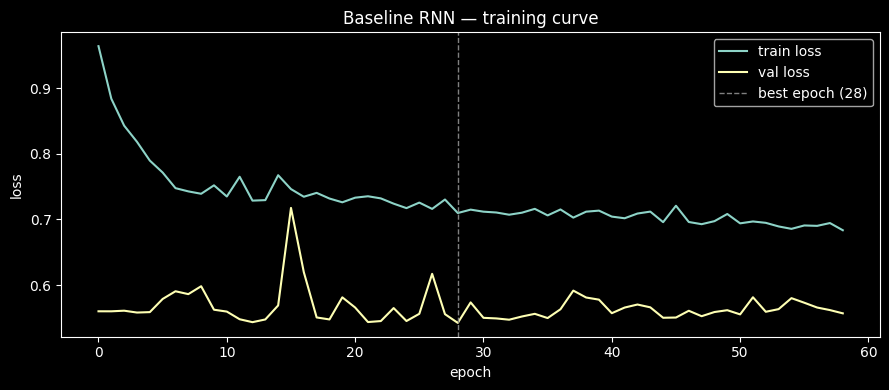

In [23]:
trainer.plot_training_curve(title="Baseline RNN — training curve")

### Validation Set — Predicted vs True Distribution

Before looking at regimes, check whether the model has learned the right overall shape. If the predicted distribution is much narrower than the true one, the model is regressing toward the mean and missing extremes.

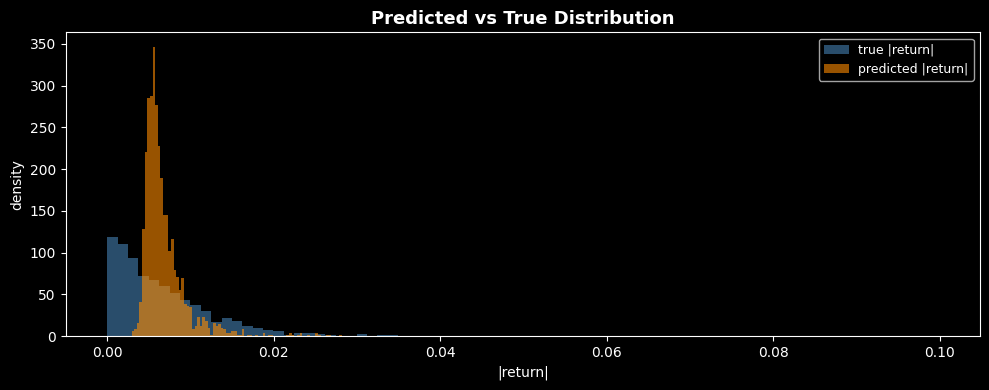

In [24]:
plot_pred_vs_true_distribution(y_val_inv, y_pred_inv)

**Observation:** The predicted distribution is narrower than the true one — the model compresses its outputs toward the mean. The tails (extreme volatility days) are systematically under-represented. This regression-to-the-mean bias is a structural consequence of MSE training: the model minimises squared error by hedging toward the center of the target distribution rather than committing to large predictions. This pattern will reappear throughout Step 2.

### Regime Evaluation

For each of the three held-out regimes: predicted vs true time series (left) and predicted vs true distribution (right). MAE per regime tells you where the model is strong and where it breaks down.

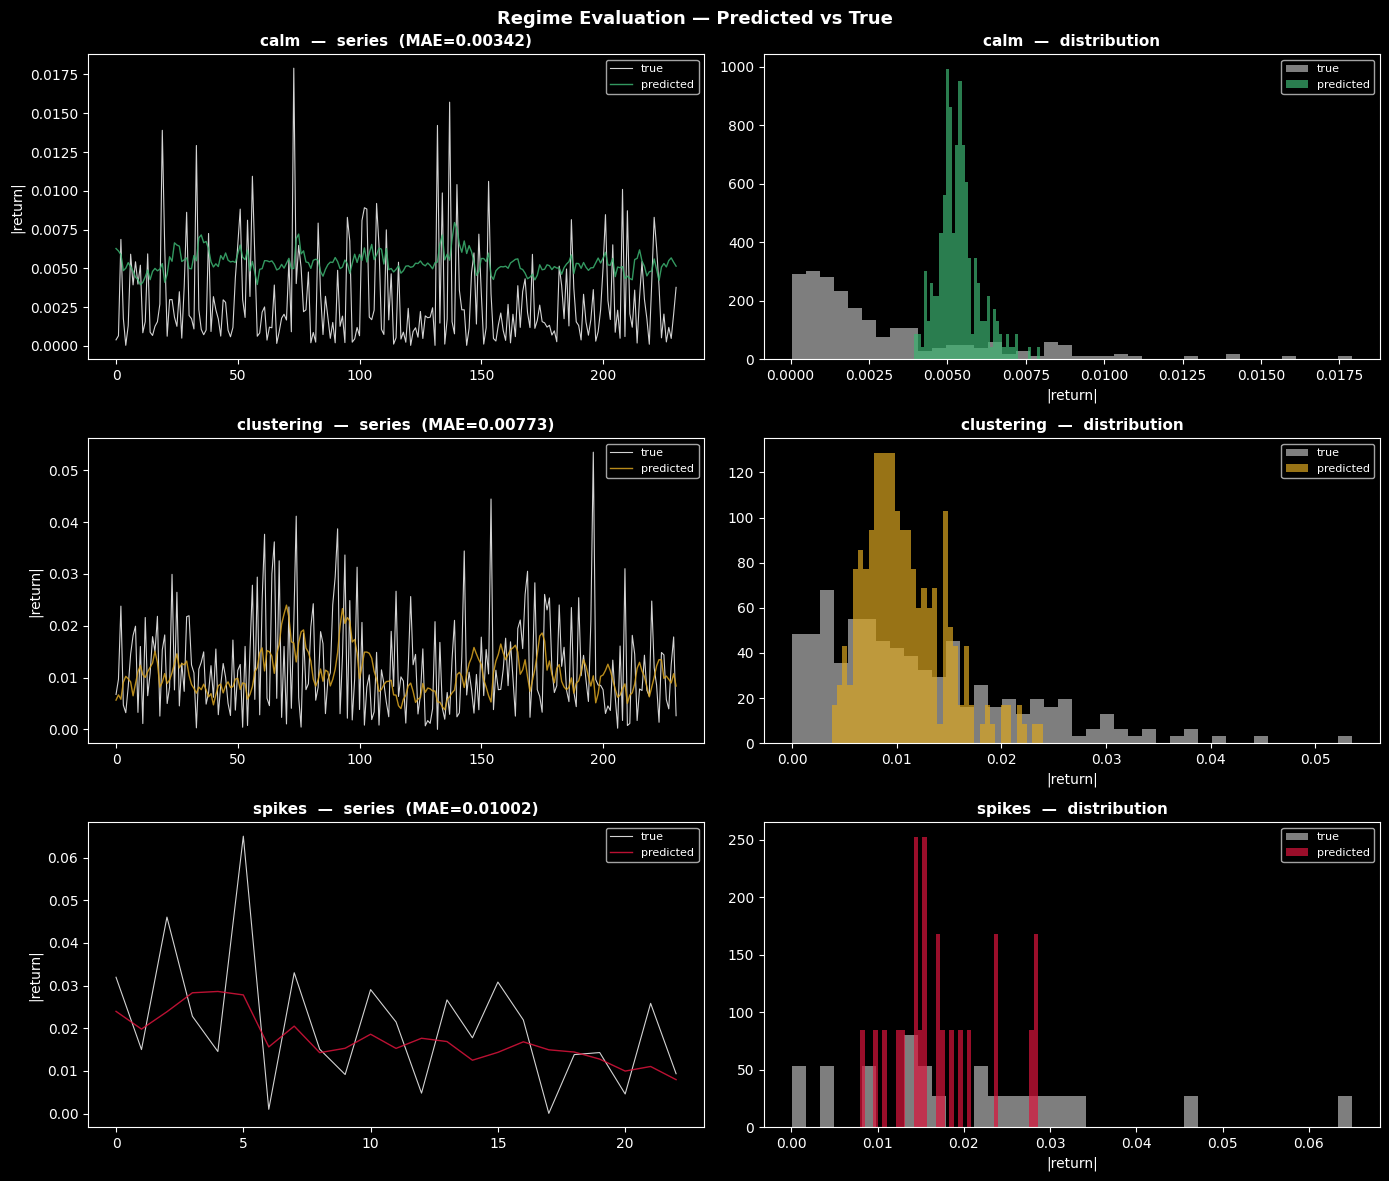

            n_days       MAE
regime                      
calm           231  0.003423
clustering     231  0.007733
spikes          23  0.010021


In [25]:
regime_results = evaluate_regimes(trainer, regime_sets, scaler_y)

**Observation:** MAE is lowest in the calm regime and highest in the spikes regime — consistent with the mean-reversion bias shown above. In calm markets the model's central-tendency predictions are accurate because true moves are also small. In the spikes regime (2020 COVID crash), the model encounters extreme moves it barely saw during training; its predictions stay near the mean while the true targets spike, producing the worst errors. The clustering regime sits between the two: the model captures the general direction of elevated volatility but still misses the magnitude.

## Grid Search — Find the Best Architecture

Runs all combinations of the param grid with a light training budget (80 epochs, early stopping 15). Results are sorted by val MAE. Use the top config to build the final model before running the deep analysis above.

In [26]:
#grid_results = grid_search_rnn(df, test_df)
#grid_results.to_csv('grid_results.csv')
df_results = pd.read_csv('grid_results.csv', index_col=0)
df_results.head()

,rank,sequence_length,hidden_size,num_layers,lr,grad_clip,val_MAE,MAE_calm,MAE_clustering,MAE_spikes
0,1,20,64,1,0.0005,0.5,0.004219,0.002860,0.008079,0.009979
1,2,30,64,2,0.0010,0.5,0.004228,0.002948,0.007597,0.008271
2,3,20,32,2,0.0005,1.0,0.004229,0.002763,0.007710,0.010274
3,4,10,64,2,0.0010,0.5,0.004238,0.002633,0.007917,0.015570
4,5,30,32,1,0.0005,0.5,0.004242,0.003222,0.007692,0.007998


# Analysis Roadmap

The sections below lay out the full analysis pipeline from this baseline to advanced RNN architectures. Each section has a clear goal and a concrete output. Work through them in order.

---

**Three questions this analysis answers:**

1. **Does the RNN actually use its sequence memory?** (Steps 1.2, 1.3, 3.1, 3.2) — Hidden state activity and input sensitivity show whether the model exploits temporal context, or just treats the last few inputs like a flat FNN would.

2. **Where and why does the model fail?** (Steps 2.1, 2.2, 2.3) — Error analysis across regimes reveals the mean-reversion bias: the model systematically underestimates spikes. Weight distributions (Step 1.1) explain the structural reason.

3. **Was `SEQUENCE_LENGTH=20` justified?** (Steps 3.0, 3.1, 3.2) — The W_hh spectral radius gives the theoretical answer; gradient norms and effective memory give the empirical one. Together they quantify the true memory depth and whether a longer sequence would add signal.

## Step 1 — What Did the Model Actually Learn?

Before tuning anything, it's worth asking: what did the model do with the data? Three angles give a fairly complete picture.

The weight distributions (1.1) show whether training moved the parameters meaningfully or left them near their initialisation. The hidden state activity (1.2) shows whether the model builds up context as it processes the sequence, or whether the recurrent pathway is essentially a pass-through. The input sensitivity (1.3) is the most direct test of whether the RNN is doing anything a flat FNN couldn't do — if sensitivity is uniform across all lags, the hidden state is not contributing.

Together, these three plots tell you whether the sequence architecture earned its complexity.

### 1.1 — Weight Distributions

Three matrices drive this model: `W_ih` (input → hidden, reads new data at each step), `W_hh` (hidden → hidden, the memory matrix), and the head weights (hidden → output, forms the final prediction).

`W_hh` is the one to watch. A distribution squeezed near zero means the hidden state barely survives from one step to the next — the model would be functionally equivalent to ignoring the sequence. A healthy `W_hh` has moderate spread around zero, large enough to propagate information across steps.

If `W_hh` looks nearly unchanged from its initialisation after training, that is a red flag: the recurrent pathway learned nothing and the model is only using the most recent input through `W_ih`.

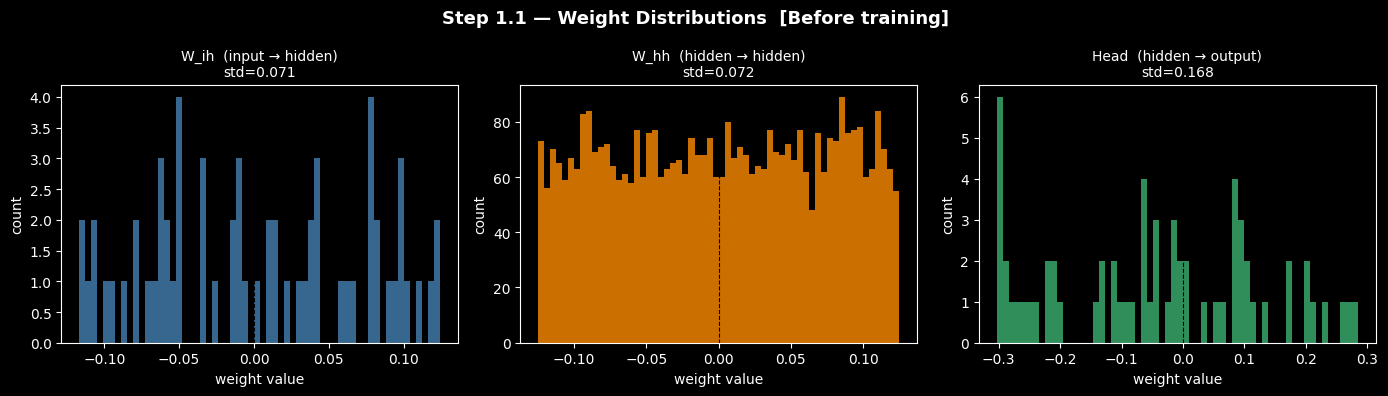

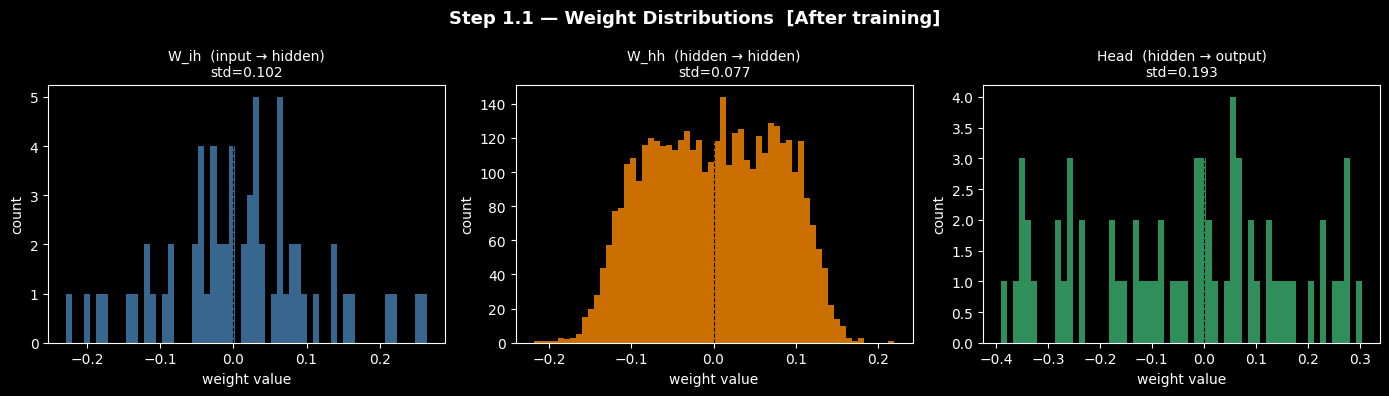

In [27]:
plot_weight_distributions(Rnn_before, title="Before training")
plot_weight_distributions(Rnn_simple, title="After training")

**Observation:** After training, `W_hh` (hidden-to-hidden) is the most visibly reshaped matrix — its distribution widens and develops more structure relative to the Xavier initialization. `W_ih` and the head weights shift more modestly. This is expected: `W_hh` is the recurrent pathway where the model learns what to remember across steps. If it stayed near its initial distribution, the hidden state would carry no meaningful memory. The fact that it changes confirms the recurrent pathway is actively contributing — not acting as a pass-through.

### 1.2 — Hidden State Activity Over Time

This plot shows the average activation level of the hidden state at each position in the input sequence (0 = oldest input, T = most recent).

Even before training, the activity climbs — this is expected. The hidden state is initialised to zero, so at step 1 the model has only one input's worth of signal, at step 2 it has two, and so on. The warmup from zero produces a rising curve regardless of what the weights are. What matters is not whether the curve rises, but **how its shape changes after training**.

After training, if the slope steepens or the curve develops a more structured profile, that means the model learned to accumulate context more aggressively across steps. If the shape is nearly identical to the pre-training curve, the recurrent pathway learned very little — the model is essentially relying on the warmup effect rather than on what it trained `W_hh` to do.

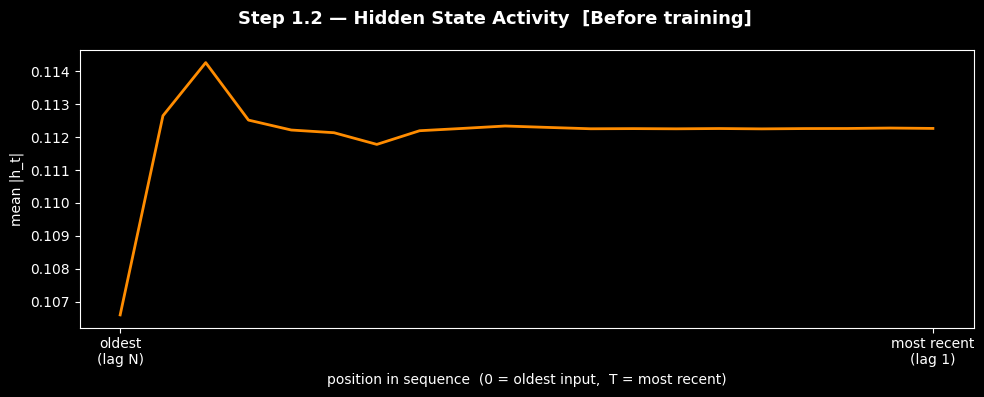

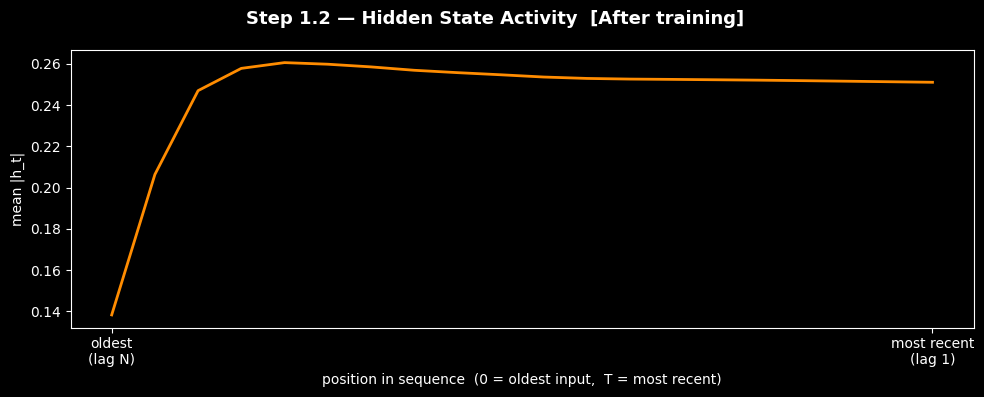

In [28]:
plot_hidden_state_activity(Rnn_before, X_val, title="Before training")
plot_hidden_state_activity(Rnn_simple, X_val, title="After training")

**Observation:** Both curves rise then plateau — the shape is identical, but the scale is not. Before training the hidden state saturates around 0.125; after training it saturates around 0.325, roughly 2.5× higher. This means `W_hh` learned to maintain a much more active hidden state across the sequence. The recurrent pathway is contributing.

The plateau shape itself is informative: activity stops accumulating after the first ~20–30% of the sequence, which is consistent with what Step 3 will show — the model effectively stops absorbing new context after a few steps. The curve does not keep climbing all the way to lag 1; the hidden state reaches a kind of steady state, reflecting the limited effective memory of a vanilla RNN.

### 1.3 — Input Sensitivity by Lag

Each bar answers: how much does changing the input at that lag position move the final prediction? Lag 1 is yesterday, lag N is N days ago.

Before training, the untrained `W_hh` doesn't propagate signal — the hidden state at step T barely remembers what happened at step T-5. You would expect almost all sensitivity to be concentrated in the last 1–2 lags. After training, if the model successfully learned to use historical context, sensitivity should spread across the full window with a gradual decay.

The comparison between the two plots is the real test of whether the recurrent pathway learned anything at all.

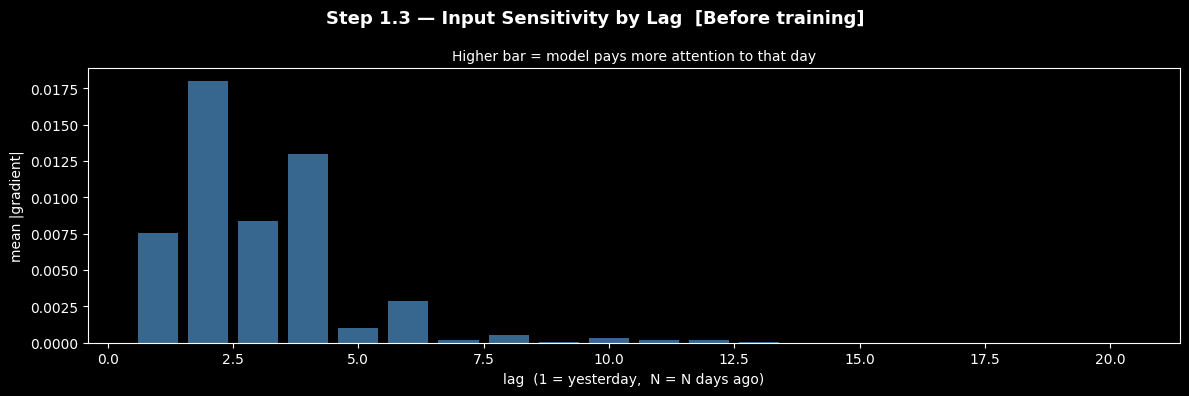

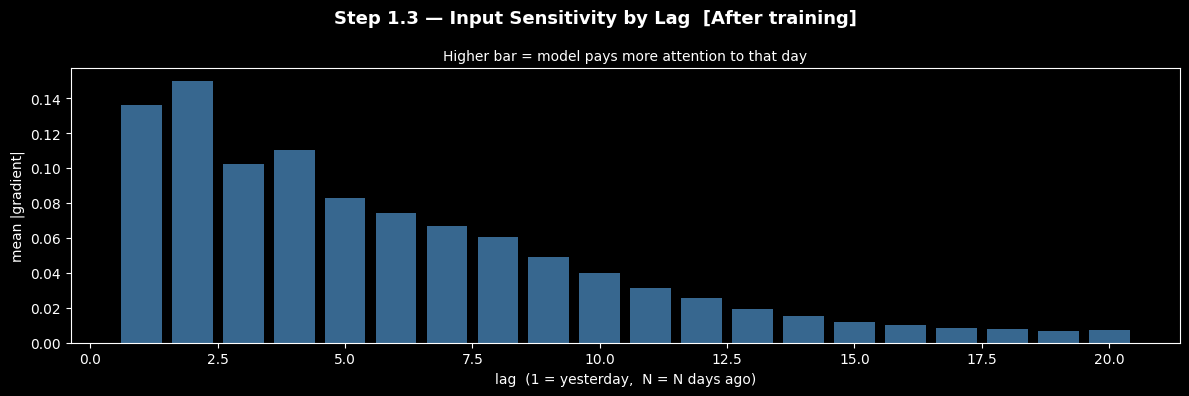

In [29]:
plot_input_sensitivity(Rnn_before, X_val, title="Before training")
plot_input_sensitivity(Rnn_simple, X_val, title="After training")

**Observation:** The change between before and after training is striking. Before training, sensitivity collapses within the first 2–3 lags — the untrained `W_hh` doesn't propagate signal, so only the most recent input actually reaches the prediction. After training, the model distributes sensitivity broadly across the full 20-lag window, with a gradual decay rather than a hard cutoff.

This means training genuinely taught the model to use historical context — the recurrent pathway is working. The decay is still there (recent lags have ~2–3× the sensitivity of the oldest), but nothing drops to zero. This is a more optimistic picture than a naive "vanishing gradient kills everything beyond lag 5" story.

## Step 2 — Where Does It Fail?

The overall MAE gives a single number, but it hides more than it reveals. A model that is mediocre everywhere can look identical to one that is excellent on calm days and completely wrong on volatile ones.


### 2.1 — Residuals Over Time

For each regime, the white line is the true absolute return and the coloured area is the absolute prediction error `|true − predicted|`. When the error area closely tracks the true return, the model is making its biggest mistakes on the biggest moves — which is the mean-reversion bias in time-series form.

A well-calibrated model would show a flat error band regardless of what the true return is doing. What we expect to see here is the opposite: the error spikes wherever the true return spikes.

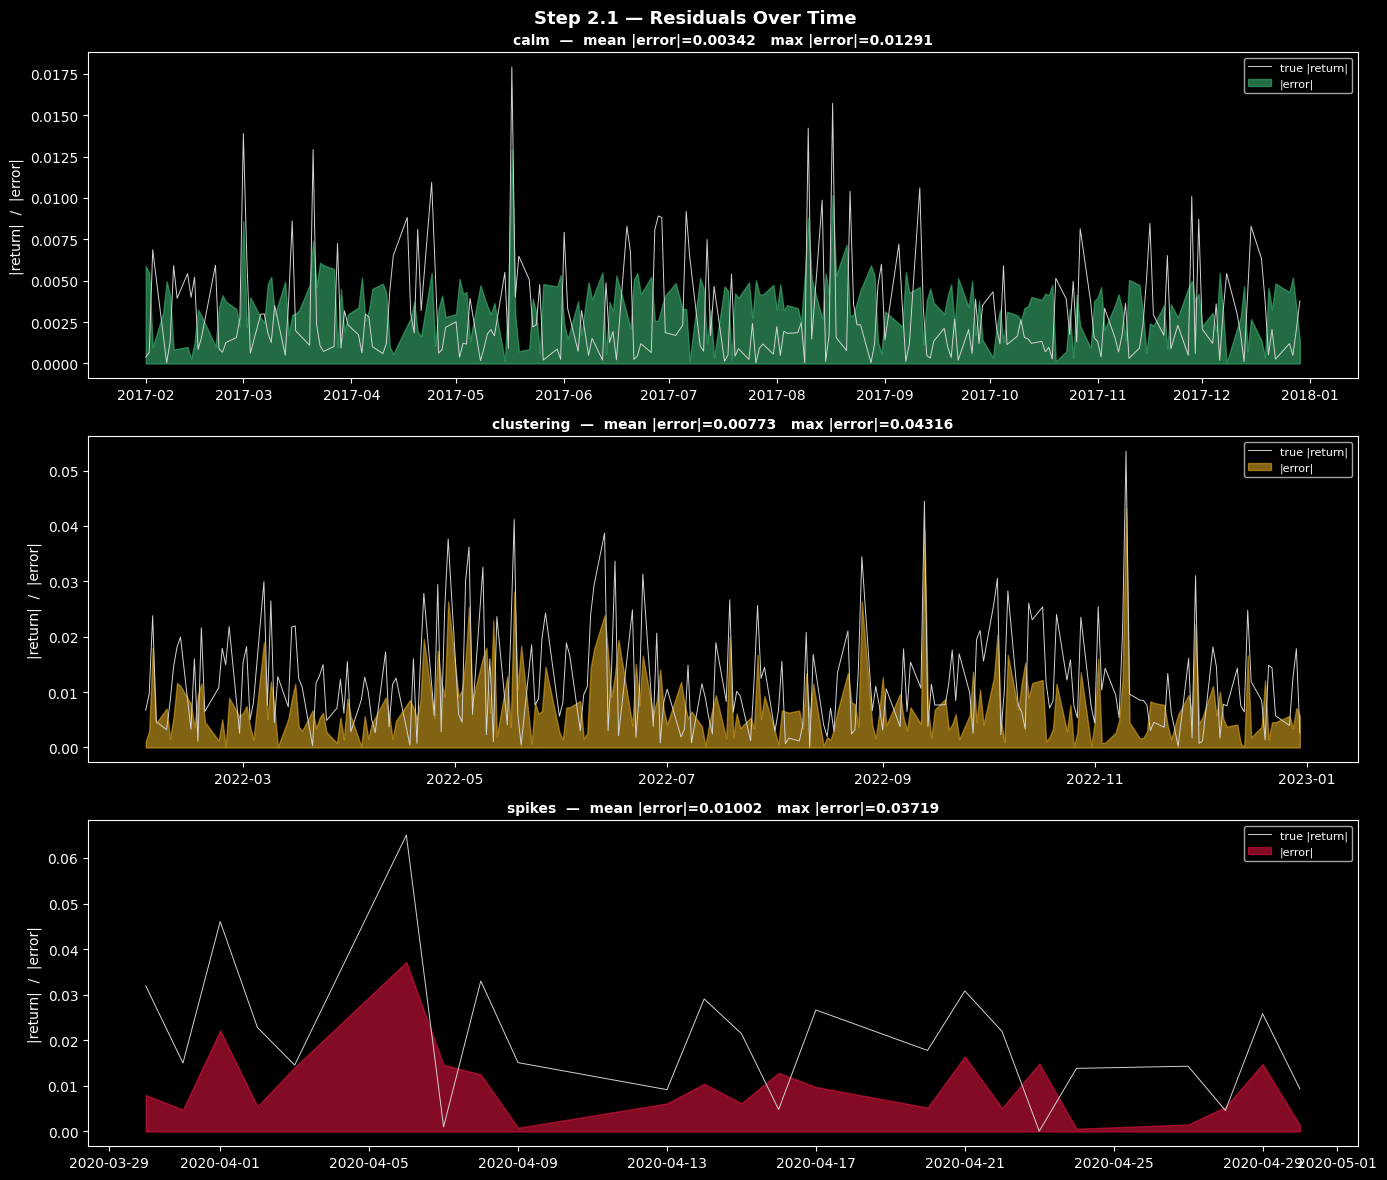

In [30]:
plot_residuals_over_time(trainer, regime_sets, scaler_y, test_df, SEQUENCE_LENGTH)

**Observation:** Residuals are small and stable in the calm regime, moderately elevated in the clustering regime, and spike sharply during the 2020 COVID crash. The model's worst moments align exactly with the worst moments in the market. This is not random noise — the error variance is directly proportional to volatility magnitude, which confirms the mean-reversion bias: the model predicts near the mean when the true target is extreme, producing a large error exactly when accurate prediction would matter most.

### 2.2 — Error vs Magnitude

The scatter on the left plots the true volatility against the prediction error for each sample, with the three regimes in different colours. The dashed line is the overall linear trend, the positive slope is the signature of the mean-reversion bias: the larger the true move, the more the model underestimates it.

The signed-error histograms on the right (`predicted − true`) show the direction of the bias per regime. A histogram shifted left of zero means systematic under-prediction. The spikes regime should shift furthest left — the model keeps predicting near the mean while the true target is extreme.

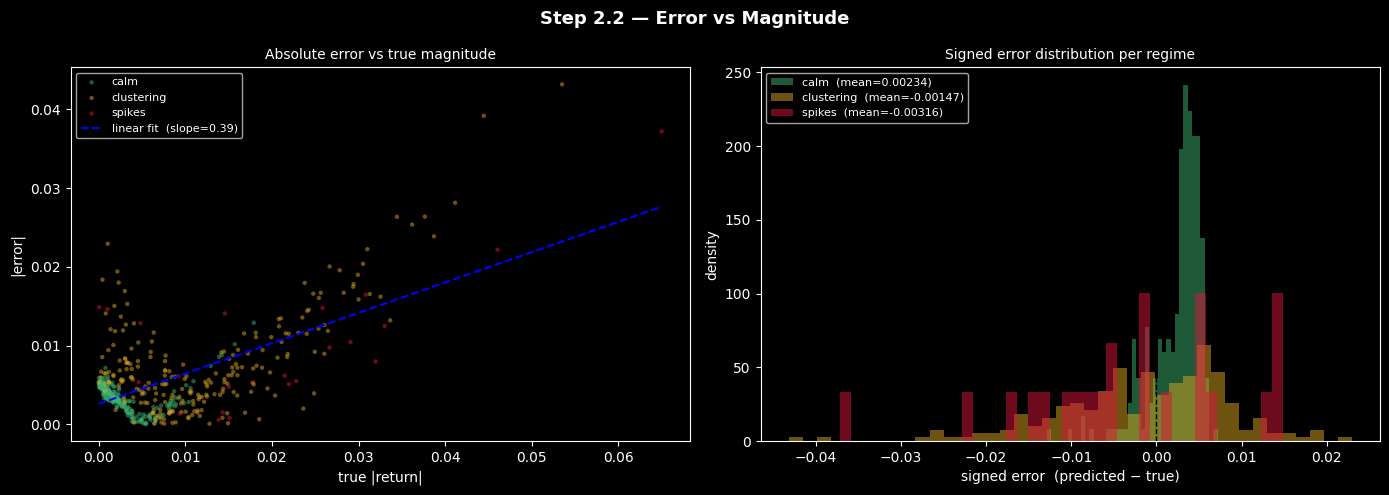

In [31]:
plot_error_vs_magnitude(trainer, regime_sets, scaler_y, test_df, SEQUENCE_LENGTH)

**Observation:** The positive slope on the overall fit confirms mean-reversion bias: the larger the true move, the more the model underestimates it. The signed-error histograms agrees, the spikes histogram is shifted furthest left of zero (systematic under-prediction), while the calm histogram is nearly centred. The model is most wrong on the days that matter most and most accurate on the days that matter least. This could be a consequence of the loss function: MSE penalises all errors equally, so the model learns to be mediocre everywhere rather than correct on extremes.

### 2.3 — Worst Predictions Per Regime

These are the worst 5% of predictions in each regime, with the actual date in the subplot title. The blue line is the input lookback window the model saw; the purple line is the true target; the red dot is the prediction.

Looking at these cases together usually reveals a pattern. If most failures share a common shape — for example, a flat calm input window followed by a sudden spike — that is a structural blind spot. The model had no signal in its context to anticipate the move. If the failures look visually diverse, the errors are driven purely by magnitude rather than by any identifiable sequence shape the model could in principle learn to recognise.

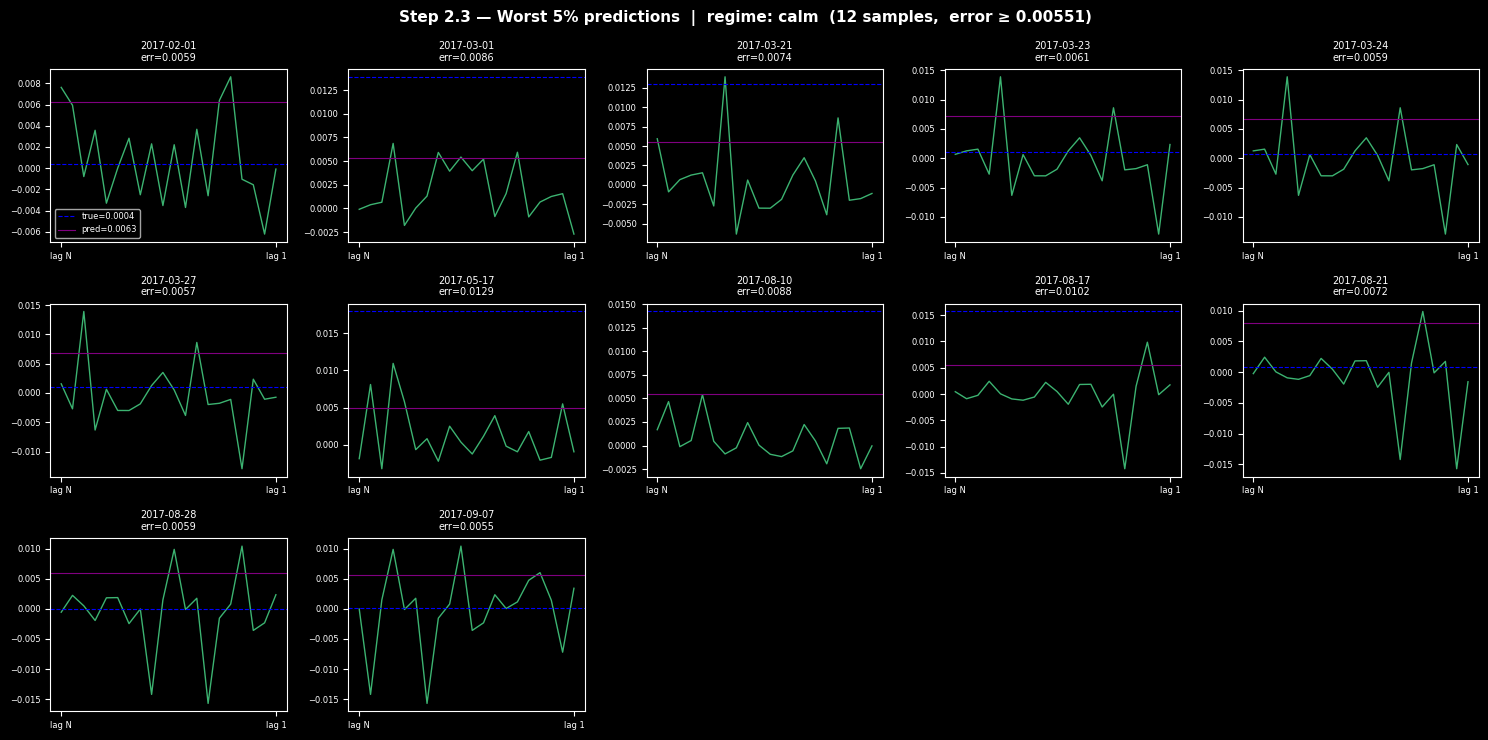

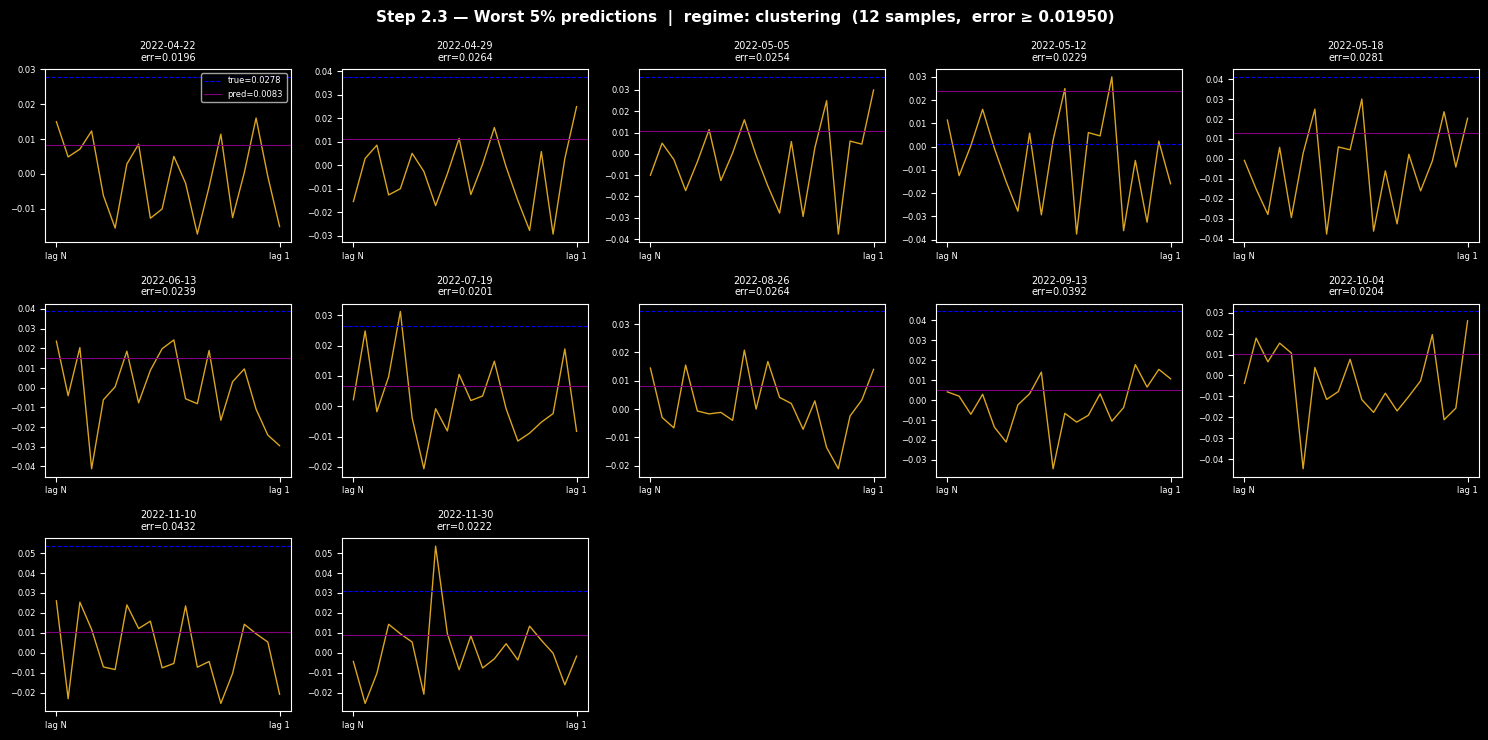

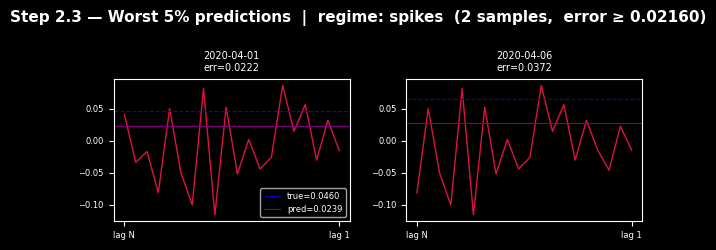

In [32]:
plot_worst_predictions(trainer, regime_sets, scaler_y, scaler_X, test_df, SEQUENCE_LENGTH)

**Observation:** The calm and clustering failures have no identifiable pattern — they are simply the days where the true value was largest within the regime. Nothing the model could have done differently.

The spikes cases are more instructive. Both worst predictions (2020-04-01 and 2020-04-06) have an input window that is already showing extreme COVID-level volatility. The model was not blindsided by a sudden jump from calm — it had full context of the crash unfolding. It still predicted ~0.015 when the true value was ~0.046. The failure is not about memory or sequence length: the model simply cannot output a number that large because it never saw targets like that during training. The output layer has no weight configuration that maps to ~0.046 — it was never learned.

## Step 3 — Vanishing Gradient Diagnosis

Every time the RNN takes a backward step through time, the gradient is multiplied by `W_hh^T`. If the singular values of `W_hh` are smaller than 1 — which is almost always the case for a vanilla tanh RNN — the gradient shrinks at every step. After 20 steps back, a spectral radius of 0.9 gives `0.9^20 ≈ 0.12`, and the optimizer can no longer distinguish "step 15 mattered" from "step 15 was noise". The network forgets.

This is the vanishing gradient problem. It is not a bug you can fix by tuning the learning rate — it is a structural property of the architecture. The only real solutions are gated cells (LSTM, GRU) that carry information across large time gaps, or attention mechanisms that let gradients skip directly to any past step.

There is a separate but related problem: **exploding gradients**. During some batches — particularly when the input contains a sudden volatility spike — the gradient norm can briefly grow to destabilising values before the average decay kicks in. This is why the training loop uses **gradient clipping** (`max_norm = 0.5`): if the global gradient norm exceeds 0.5, all gradients are scaled down proportionally before the weight update. Clipping does not fix vanishing gradients; it only prevents the rare but catastrophic explosive batches from corrupting the weights. Think of it as a safety valve, not a cure.

Steps 3.0, 3.1, and 3.2 measure how severe the vanishing is in our trained model — from three different angles that should converge to the same answer.

### 3.0 — W_hh Spectral Radius (Theoretical Memory Limit)

Before measuring gradient norms empirically, it's worth understanding the theoretical reason gradients vanish. The hidden state evolves as:

```
h_t = tanh(W_ih · x_t + W_hh · h_{t-1} + b)
```

During BPTT, gradients flow back through repeated multiplication by `W_hh^T`. The spectral radius σ₁ (largest singular value of `W_hh`) determines what happens at each step:

- **σ₁ < 1** → gradients shrink (vanishing)
- **σ₁ > 1** → gradients grow (exploding)
- **σ₁ ≈ 1** → gradients are preserved

**Left graph:** W_hh is a 64×64 matrix, so it has 64 singular values — one per direction in the hidden state space. Each dot is one of those directions, ranked from largest to smallest. The y-value tells you what happens to a gradient pointing in that direction when it passes through `W_hh^T`: above the red line it gets amplified, below it shrinks. It's essentially a "gradient fate per direction" chart.

**Right graph:** the distribution of all those singular values — where most of the 64 directions actually sit.

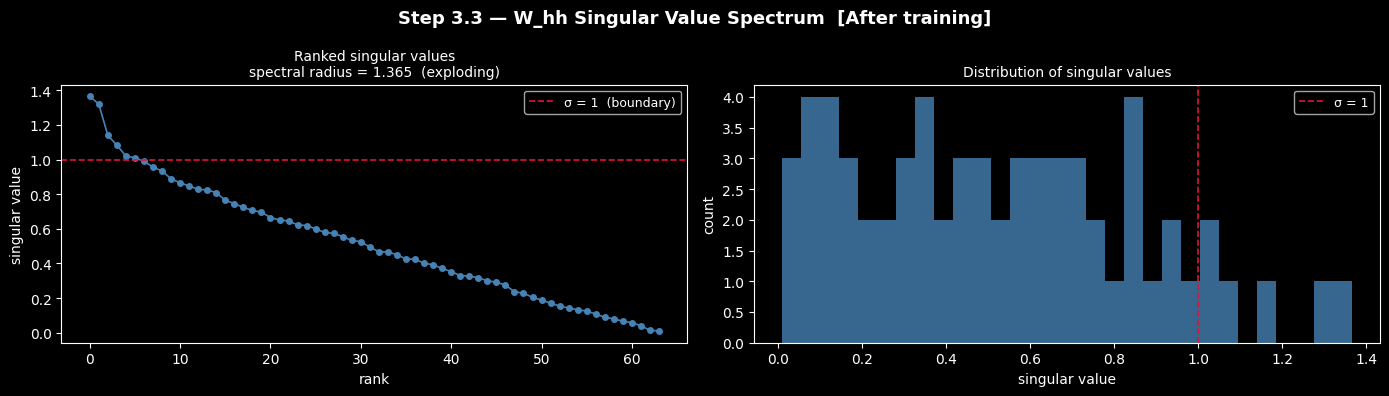

In [33]:
plot_whh_spectrum(Rnn_simple, title="After training")

**Observation:** What's interesting here is that it's not a clean story. The spectral radius is 1.4, so technically W_hh is in the "exploding" regime . Looking at the distribution on the right, most of the 64 directions sit well below 1. So the picture is really: a handful of directions (~5–7, those above the red line on the left) are amplifying gradients, while the remaining ~57 are killing them.

Training seems to have pushed those top directions above 1 deliberately — it's the only way the model could maintain any gradient flow at all through 20 steps of tanh saturation. Without them, backprop would have nothing to work with. That also explains why gradient clipping is necessary: those same amplifying directions are the ones that can destabilise training if left unchecked.

### 3.1 — Output Sensitivity per Time Step (BPTT)

Despite the label on the y-axis, this plot does not measure whether training converged. It measures `d(output)/d(h_t)`: how much does the final prediction change if you perturb the hidden state at step t. This is a property of the model's Jacobian — it does not go to zero just because training finished.

What it reveals is structural: does the prediction depend on what the hidden state was 5 steps ago, or only on the most recent step? The gradient flows backward through the chain `h_T → h_{T-1} → ... → h_t`, passing through `W_hh^T` at each step. If most singular values of `W_hh` are below 1, this product shrinks with each step and the curve collapses — meaning the output is insensitive to older hidden states regardless of how well the model is trained.

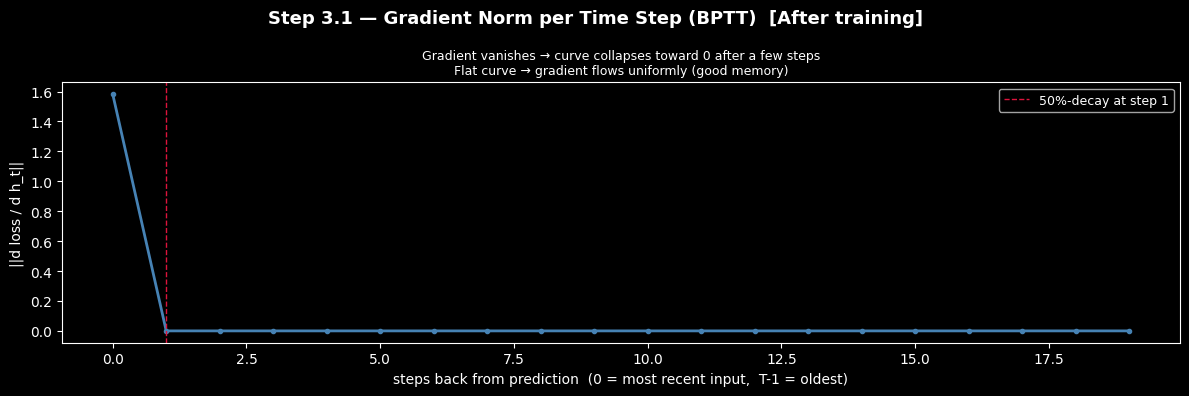

In [34]:
plot_gradient_norms(Rnn_simple, X_val, title="After training")

**Observation:** The output sensitivity collapses within 1 step — the 50%-decay is already at step 1, and by step 2 the curve is essentially zero. The prediction has almost no sensitivity to any hidden state older than 1 step back, which means changing what happened 5 days ago barely moves the output at all.

This seems to contradict Step 1.3, where the model showed sensitivity to the full 20-lag window. The resolution is that these measure different things. Step 1.3 perturbs the **inputs** and measures the change in output — information from older inputs physically flows forward through the hidden state and reaches the prediction. Step 3.1 perturbs the **hidden states** and measures the same change, but flowing backward. Older hidden states have near-zero Jacobian with the output, meaning the model's effective decision-making is concentrated at the last 1–2 steps, even if older inputs left a trace in the hidden state.

### 3.2 — Effective Memory Length

Rather than measuring gradient flow, this looks at the output: how correlated is the final hidden state `h_T` with each input `x_t` at different lags? High correlation at lag 1 but near-zero at lag 15 means the hidden state, at the moment of prediction, carries almost no information from 15 days ago — regardless of whether those days were volatile or not.

This is the empirical complement to the gradient norm plot. Both should point to the same effective memory depth. If they agree, we have convergent evidence. If they disagree, one of them is picking up a confound worth investigating.

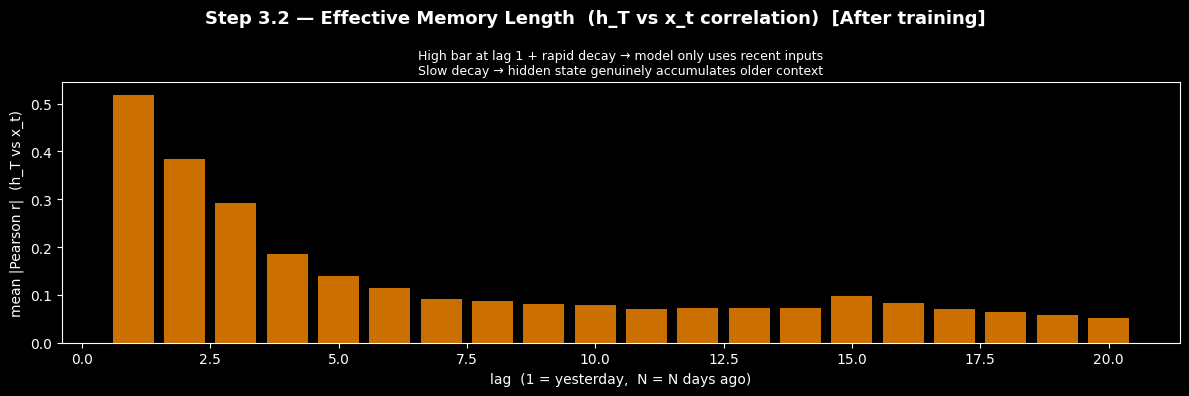

In [35]:
plot_effective_memory(Rnn_simple, X_val, title="After training")

**Observation:** The correlation decays gradually across the full 20-lag window — `h_T` is still meaningfully correlated with inputs from 15–20 days ago. This seems to contradict Step 3.1, but the two plots are actually measuring different things and are compatible.

Step 3.1 measures **local linear sensitivity**: if you perturb h_t by a small amount, does the output change? That collapses at step 1, because d(h_T)/d(h_t) is near zero — small perturbations to older hidden states do not propagate forward to h_T.

Step 3.2 measures **global nonlinear correlation**: did older inputs shape h_T through the full forward dynamics? They did — 20 steps of forward accumulation left a trace. These two things are compatible. A function can be highly correlated with a variable while having a near-zero local derivative (think of a saturated sigmoid: output is correlated with input, but gradient is flat). The head fully uses h_T, and h_T does encode older history — the Jacobian collapse in 3.1 does not mean that information is lost, only that it cannot be accessed via small linear perturbations.

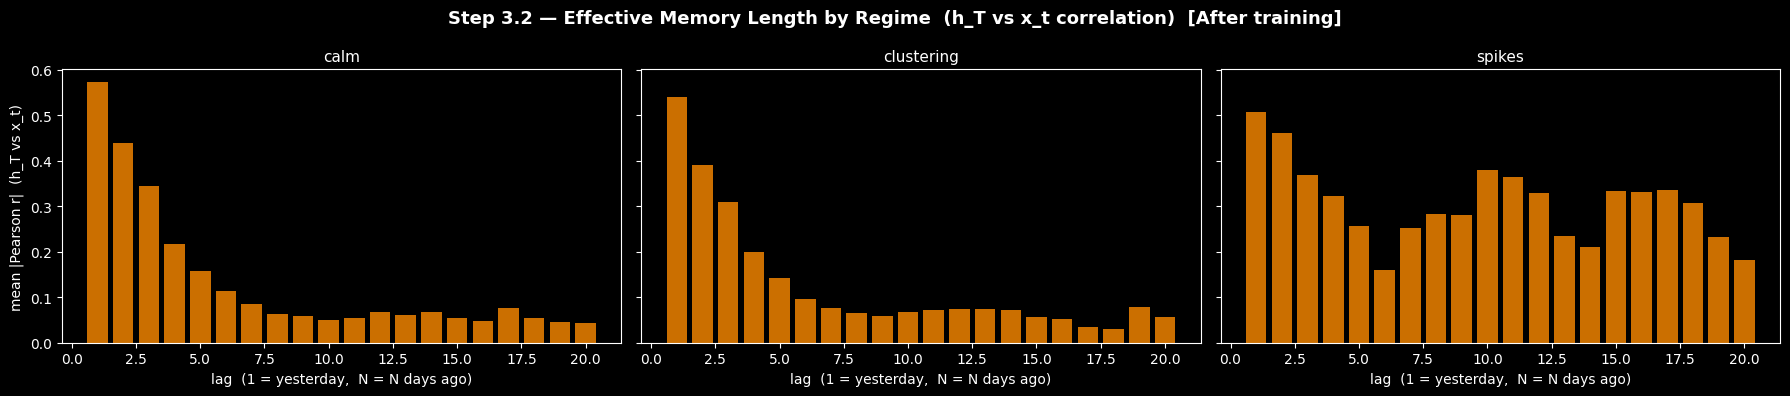

In [36]:
plot_effective_memory_by_regime(Rnn_simple, regime_sets, title="After training")

**Observation (by regime):** The three regimes have clearly different patterns.

**Calm** decays smoothly from ~0.55 at lag 1 down to a flat plateau around 0.05–0.12 for lags 5–20 — the hidden state encodes recent history cleanly, with a small but persistent trace of older inputs.

**Clustering** follows a similar shape but drops more sharply — correlation falls faster and reaches near-zero by lag 6. The hidden state in clustering periods is more focused on the most recent few days.

**Spikes** is the anomaly: it has the highest overall correlations (~0.60 at lag 1) and a non-monotonic pattern, with secondary peaks re-emerging around lags 7–11 and 12–17. This makes sense for the COVID crash: every day in the lookback window was extreme, so the hidden state correlates with inputs from many different lags, not just the most recent ones. The non-monotonic shape likely reflects the autocorrelation structure of the crash itself — extreme days were clustered, creating repeating patterns that the hidden state picks up at multiple lag distances.

## Step 4 — Reading the Grid Search Results

The grid search ran all 48 combinations of sequence length, hidden size, number of layers, learning rate, and gradient clipping, with a light training budget. The table above shows the full ranking by validation MAE.

The first thing to notice: the top-to-bottom range across all 48 configurations is only **0.00042** (from 0.00422 to 0.00449). No combination of hyperparameters broke out of this band. We are close to the ceiling of what this architecture can do on this problem.

The second thing to notice: the configuration that ranks #1 on aggregate MAE is **not** the best on the spikes regime. The choice of metric matters as much as the choice of hyperparameters.

48 configurations, and the spread from best to worst is 0.00042. That's basically nothing. No matter what we tuned, we couldn't get out of this band — which tells you the problem isn't hyperparameters, it's the architecture itself.

The one thing that does move the needle is sequence length, but only on the spikes regime. Short sequences (seq_len=10) are consistently bad there — around 0.015–0.017 MAE — while seq_len=30 clusters around 0.008. The reason makes sense now: the forward pass does accumulate 30 lags of history into h_T (Step 3.2 showed the correlation doesn't drop to zero), so a longer window gives the model more context to work with, even if the gradient can only flow back 1 step during training.

**Observation:** The longer window (seq=30) meaningfully improves the spikes regime — that's the whole point of the exercise. Calm gets slightly worse, which makes sense: a 30-day window in a quiet period is just averaging over more of the same, diluting whatever recent signal exists. But on spikes, the extra context genuinely helps — the COVID crash was a sustained regime, so having 30 days of extreme moves in the window rather than 20 gives the hidden state a clearer picture of what kind of market it's in.

This confirms what Step 3.2 suggested: the forward pass does accumulate history meaningfully beyond lag 20, and that extra context is useful when the regime is persistent. The model isn't using those older lags via gradient-trained weights — it's using them through the forward dynamics of h_T, which is enough to move the needle on a regime that lasted weeks.

## Global Conclusion

Three things stood out from this analysis.

**The mean-reversion bias is an output range problem more than a loss function problem.** The worst predictions on the spikes regime weren't cases of missing context — the full COVID crash was visible in the input window. The model predicted 3× too low not because it lacked memory but because it was never trained to output values that large. The training distribution simply didn't contain enough extreme targets to push the head weights into that range. Changing the loss to MAE or Huber would reduce the pull toward the mean, but the out-of-distribution gap is the harder part.

**Sequence length matters, but for the right reason.** Longer windows (seq=30) genuinely help on spikes, and Step 3.2 explains why: the hidden state accumulates forward-pass history from all 30 lags, so the model gets a clearer picture of a persistent regime like the COVID crash. This has nothing to do with the gradient flowing back 30 steps — it collapses at step 1. The benefit is purely from the forward dynamics. Calm performance suffers slightly because a longer window in a quiet market just dilutes the recent signal.

**The ceiling is the architecture, not the hyperparameters.** 48 configurations, 0.00042 MAE spread. The model is structurally limited by the fact that the head only ever learns from the most recent step's gradient signal, even though the hidden state carries 30 lags of history. The memory is there — training just never reinforced learning to read it.